going to use mnist dataset to train a neural network made from scratch, meaning we dont use any deeplearning framework like tensorflow and pytorch. the mnist contains handwriting.

# Building a Neural Network from Scratch for MNIST Digit Classification

In this notebook, we're going to build a neural network from the ground up—no TensorFlow, no PyTorch, just pure Python and NumPy. By the end, there will be a working classifier that can recognize handwritten digits from the MNIST dataset.

## What Does a Neural Network Do?

Think of a neural network as a pattern-recognition machine. It takes input data (like pixel values from an image), passes that data through layers of interconnected "neurons," and produces an output (like a prediction of which digit 0-9 is shown). During training, the network learns which patterns matter by adjusting the strength of connections between neurons. It's loosely inspired by how biological neurons work in our brains, but much simpler!

## Our Roadmap

We'll build our neural network step by step:

1. **Load the Data**: Import the MNIST dataset and prepare it for training
2. **Build the Forward Pass**: Implement how data flows through the network to make predictions
3. **Define the Loss Function**: Measure how wrong our predictions are
4. **Implement Backpropagation**: Calculate gradients to figure out how to adjust our weights
5. **Train the Model**: Use gradient descent to iteratively improve our network
6. **Evaluate Performance**: Test our trained network on unseen digits

### Detailed Roadmap Breakdown

Each phase below represents a key milestone in building our neural network. We'll approach this systematically, following the Elegant Programmer's Bible principles: clear logic flow, explicit choices, and single responsibility.

---

#### **Phase 1: Data Loading & Exploration**
**Goal**: Understand our dataset before touching any neural network code.

- Import MNIST dataset (70,000 handwritten digit images)
- Inspect data shapes: `(samples, features)` where features = 784 pixels (28×28 flattened)
- Visualize sample images to understand what we're working with
- Check pixel value ranges (0-255) and label distribution (digits 0-9)

**Why this matters**: Neural networks are sensitive to input data. Understanding the data first prevents hours of debugging later.

---

#### **Phase 2: Data Preprocessing**
**Goal**: Transform raw data into a format optimized for neural network learning.

- **Normalization**: Scale pixel values from [0, 255] to [0, 1]
  - *Why*: Prevents large input values from dominating gradient calculations
  - *Decision*: Use simple division by 255 rather than StandardScaler (simpler, equally effective for pixel data)

- **Train-Test Split**: Separate data into training (80%) and testing (20%) sets
  - *Why*: Need unseen data to evaluate true model performance
  - *Reproducibility*: Set `random_state=42` for consistent results

- **One-Hot Encoding**: Convert labels from integers (0-9) to vectors
  - Example: digit `3` becomes `[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]`
  - *Why*: Softmax output layer produces probabilities for each class; labels must match this format

---

#### **Phase 3: Build the Forward Pass**
**Goal**: Implement how data flows through the network to make predictions.

- **Architecture Design**: Define layer sizes `[784 → 128 → 64 → 10]`
  - Input: 784 pixels
  - Hidden layers: 128 and 64 neurons (progressively compress information)
  - Output: 10 neurons (one per digit class)

- **Weight Initialization**: Random small values (~0.01) to break symmetry
  - *Why not zeros*: All neurons would learn the same thing
  - *Why not large values*: Causes exploding/vanishing gradients

- **Forward Propagation Steps**:
  1. Linear transformation: `Z = X @ W + b`
  2. Activation: `A = ReLU(Z)` for hidden layers, `Softmax(Z)` for output
  3. Cache intermediate values (needed for backpropagation)

**Key Decisions**:
- ReLU activation: `max(0, x)` - simple, prevents vanishing gradients
- Softmax for output: Converts raw scores to probabilities that sum to 1

---

#### **Phase 4: Define the Loss Function**
**Goal**: Measure how wrong our predictions are.

- **Cross-Entropy Loss**: `-Σ(y_true × log(y_pred)) / m`
  - Penalizes confident wrong predictions heavily
  - Standard choice for multi-class classification

- **Numerical Stability**: Clip predictions to prevent `log(0)` errors

**Why this loss?** It's mathematically elegant with softmax - the derivative simplifies to `(y_pred - y_true)`, making backpropagation cleaner.

---

#### **Phase 5: Implement Backpropagation**
**Goal**: Calculate gradients to know how to adjust weights.

- **Chain Rule Application**: Work backwards from output to input
  - Start with loss gradient w.r.t. output: `dL/dA_output = y_pred - y_true`
  - For each layer, compute: `dL/dW`, `dL/db`, `dL/dA_prev`
  - Use cached values from forward pass

- **Gradient Calculations**:
  - Weight gradient: `dW = A_prev.T @ error`
  - Bias gradient: `db = sum(error, axis=0)`
  - Error propagation: `error_prev = error @ W.T`

**Critical Detail**: Apply activation derivatives (ReLU') in hidden layers but not output (already handled in cross-entropy derivative).

---

#### **Phase 6: Train the Model**
**Goal**: Iteratively improve the network by adjusting weights.

- **Stochastic Gradient Descent (SGD)**:
  - Shuffle data each epoch (prevents learning order-dependent patterns)
  - Process in mini-batches (size=128) for efficiency
  - Update rule: `W = W - learning_rate × dW`

- **Hyperparameters**:
  - Learning rate: `0.01` (balances convergence speed vs stability)
  - Epochs: `50` (complete passes through training data)
  - Batch size: `128` (compromise between speed and gradient accuracy)

- **Training Loop**:
  1. Forward pass → compute predictions
  2. Calculate loss
  3. Backward pass → compute gradients
  4. Update weights
  5. Repeat for all batches

**Monitoring**: Track loss per epoch to ensure it's decreasing.

---

#### **Phase 7: Evaluate Performance**
**Goal**: Test our trained network on unseen data.

- **Metrics**:
  - Accuracy: % of correct predictions
  - Confusion Matrix: Which digits get confused with which
  - Per-class precision/recall (if needed)

- **Evaluation Process**:
  1. Run forward pass on test set (no backprop!)
  2. Convert softmax probabilities to class predictions (argmax)
  3. Compare with true labels

- **Visualization**:
  - Plot confusion matrix as heatmap
  - Show sample predictions (correct and incorrect)

**Success Criteria**: >95% accuracy on test set is typical for MNIST with this architecture.

---

### Design Philosophy Throughout

Every decision follows these principles:

1. **Explicit Over Implicit**: All hyperparameters stated clearly, not hidden
2. **Single Responsibility**: Each function does ONE thing (forward pass, loss computation, etc.)
3. **Clear Logic Flow**: Code reads like a story from data → training → evaluation
4. **Meaningful Names**: `layer_sizes`, `learning_rate`, not `ls`, `lr`
5. **Educational Value**: Comments explain "why", not "what"

Let's build this! 🚀

In [2]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.datasets import mnist  # only for data loading
# Make plots appear inline in the notebook 
%matplotlib inline

In [3]:
# Load MNIST digits
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Train images:", x_train.shape)
print("Train labels:", y_train.shape)
print("Test images:", x_test.shape)
print("Test labels:", y_test.shape)

print("Unique labels:", np.unique(y_train))

Train images: (60000, 28, 28)
Train labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)
Unique labels: [0 1 2 3 4 5 6 7 8 9]


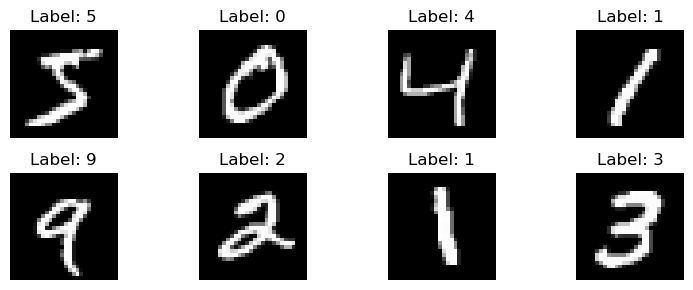

In [4]:
# Visualize first 8 training samples to understand the data
NUM_SAMPLES = 8
GRID_ROWS, GRID_COLS = 2, 4

plt.figure(figsize=(8, 3))
for i in range(NUM_SAMPLES):
    plt.subplot(GRID_ROWS, GRID_COLS, i+1)  # subplot positions are 1-indexed
    plt.imshow(x_train[i], cmap='gray')     # grayscale: 0=black, 255=white
    plt.title(f"Label: {y_train[i]}")       # show true label for verification
    plt.axis('off')                          # hide pixel coordinates
plt.tight_layout()                           # prevent subplot overlap
plt.show()

In [5]:
# Normalize pixel values from [0, 255] to [0, 1]
# Why: Prevents large input values from dominating gradient calculations
# Why float32: Half the memory of float64, sufficient precision for neural networks
PIXEL_MAX = 255.0  # Max pixel value in uint8 images

x_train = x_train.astype(np.float32) / PIXEL_MAX
x_test = x_test.astype(np.float32) / PIXEL_MAX

# Verification: Check normalization worked correctly
print(f"Pixel range after scaling: {x_train.min():.1f} to {x_train.max():.1f}")

Pixel range after scaling: 0.0 to 1.0


In [6]:
# Reshape from (samples, 28, 28) to (samples, 784)
# Why: Neural network expects flat input vectors, not 2D images
# -1 in reshape means "infer this dimension" (n_samples auto-calculated)

IMG_HEIGHT, IMG_WIDTH = 28, 28
INPUT_SIZE = IMG_HEIGHT * IMG_WIDTH  # 784 features

n_train = x_train.shape[0]
n_test = x_test.shape[0]

x_train_flat = x_train.reshape(n_train, -1)  # (60000, 784)
x_test_flat = x_test.reshape(n_test, -1)     # (10000, 784)

# Verification: Confirm shapes are correct
print(f"Flattened train shape: {x_train_flat.shape}")  # Should be (60000, 784)
print(f"Flattened test shape: {x_test_flat.shape}")    # Should be (10000, 784)

Flattened train shape: (60000, 784)
Flattened test shape: (10000, 784)


In [7]:

# ============================================================================
# PHASE 3: BUILD THE NEURAL NETWORK ARCHITECTURE
# ============================================================================
# We'll build a class-based design where the NeuralNetwork encapsulates:
# - Weight initialization
# - Activation functions (ReLU, Softmax)
# - Forward propagation logic
# - Internal state (weights, biases, cached activations)

class NeuralNetwork:
    """A fully-connected feedforward neural network from scratch.
    
    Architecture: Input → Hidden Layer 1 → Hidden Layer 2 → Output
    Uses ReLU activation for hidden layers, Softmax for output.
    """
    
    def __init__(self, layer_sizes, learning_rate=0.01, random_seed=42):
        """Initialize the neural network.
        
        Args:
            layer_sizes: List of layer dimensions [input_size, hidden1, hidden2, ..., output_size]
                        Example: [784, 128, 64, 10] means:
                            - Input: 784 features (28×28 pixels)
                            - Hidden layer 1: 128 neurons
                            - Hidden layer 2: 64 neurons
                            - Output: 10 classes (digits 0-9)
            learning_rate: Step size for gradient descent (default: 0.01)
            random_seed: Seed for reproducible weight initialization
        """
        self.layer_sizes = layer_sizes
        self.learning_rate = learning_rate
        self.num_layers = len(layer_sizes) - 1  # Number of weight matrices
        
        # Set seed for reproducibility
        np.random.seed(random_seed)
        
        # Initialize weights and biases
        self.weights = []  # List of weight matrices
        self.biases = []   # List of bias vectors
        self._initialize_weights()
        
        # Cache for storing activations during forward pass (needed for backprop)
        self.cache = {}
    
    def _initialize_weights(self):
        """Initialize weights and biases using Gaussian distribution.
        
        Why small random weights?
        - If all weights = 0, all neurons compute the same thing (symmetry problem)
        - If weights are large, activations explode/vanish
        - Gaussian(0, 0.01) is a good starting point for shallow networks
        """
        for i in range(self.num_layers):
            # Weight matrix shape: (current_layer_size, next_layer_size)
            W = np.random.randn(self.layer_sizes[i], self.layer_sizes[i+1]) * 0.01
            
            # Bias vector shape: (1, next_layer_size)
            b = np.zeros((1, self.layer_sizes[i+1]))
            
            self.weights.append(W)
            self.biases.append(b)
        
        print(f"✅ Initialized {self.num_layers} layers:")
        for i, (W, b) in enumerate(zip(self.weights, self.biases)):
            print(f"   Layer {i+1}: W{W.shape}, b{b.shape}")

print("\n🔧 Neural Network class defined!")
print("Ready to instantiate with: nn = NeuralNetwork(layer_sizes=[784, 128, 64, 10])")


🔧 Neural Network class defined!
Ready to instantiate with: nn = NeuralNetwork(layer_sizes=[784, 128, 64, 10])


In [8]:
input_dim = 784   # 28 x 28
hidden_dim = 128
output_dim = 10   # digits 0-9

In [9]:

# ============================================================================
# ADD ACTIVATION FUNCTIONS & FORWARD PASS TO NEURAL NETWORK
# ============================================================================

# Add ReLU activation
def relu(self, Z):
    """ReLU activation: max(0, x)
    
    Why ReLU?
    - Simple: zeros out negative values
    - Prevents vanishing gradients (gradient = 1 for positive values)
    - Computationally efficient
    """
    return np.maximum(0, Z)

# Add ReLU derivative
def relu_derivative(self, Z):
    """Derivative of ReLU for backpropagation.
    
    dReLU/dZ = 1 if Z > 0, else 0
    """
    return (Z > 0).astype(float)

# Add Softmax activation
def softmax(self, Z):
    """Softmax: converts raw scores to probabilities.
    
    Formula: softmax(z_i) = exp(z_i) / sum(exp(z_j))
    
    Why? Output needs probabilities summing to 1.
    
    Numerical stability: Subtract max(Z) to prevent overflow.
    """
    exp_Z = np.exp(Z - np.max(Z, axis=1, keepdims=True))
    return exp_Z / np.sum(exp_Z, axis=1, keepdims=True)

# Add Forward Propagation
def forward(self, X):
    """Compute predictions through the network (forward pass).
    
    Steps:
    1. Z = X @ W + b (linear transformation)
    2. A = activation(Z) (nonlinearity)
    3. Cache intermediate values for backprop
    
    Args:
        X: Input data, shape (batch_size, input_dim)
    
    Returns:
        A_final: Network predictions, shape (batch_size, output_dim)
    """
    # Store first activation (input itself)
    self.cache = {'A0': X}
    A = X
    
    # Propagate through all layers
    for i in range(self.num_layers):
        # Linear transformation
        Z = np.dot(A, self.weights[i]) + self.biases[i]
        
        # Apply activation
        if i < self.num_layers - 1:
            # Hidden layers: ReLU
            A = self.relu(Z)
        else:
            # Output layer: Softmax
            A = self.softmax(Z)
        
        # Cache for backprop
        self.cache[f'Z{i+1}'] = Z
        self.cache[f'A{i+1}'] = A
    
    return A

# Attach methods to NeuralNetwork class
NeuralNetwork.relu = relu
NeuralNetwork.relu_derivative = relu_derivative
NeuralNetwork.softmax = softmax
NeuralNetwork.forward = forward

print("✅ Activation functions & forward pass added!")
print("   Methods: relu(), relu_derivative(), softmax(), forward()")

✅ Activation functions & forward pass added!
   Methods: relu(), relu_derivative(), softmax(), forward()


In [10]:
# ============================================================================
# TEST THE FORWARD PASS
# ============================================================================

# Create neural network instance
print("🏛️ Building Neural Network...\n")
nn = NeuralNetwork(
    layer_sizes=[784, 128, 64, 10],  # [input, hidden1, hidden2, output]    learning_rate=0.01,
    random_seed=42
)

print("\n🚀 Testing forward pass with a small batch...")
# Test with first 5 training samples
test_batch = x_train_flat[:5]
print(f"Input shape: {test_batch.shape}")  # Should be (5, 784)

# Run forward pass
predictions = nn.forward(test_batch)
print(f"\nOutput shape: {predictions.shape}")  # Should be (5, 10)
print(f"Predictions (probabilities for each class):\n{predictions}")
print(f"\nSum of probabilities per sample: {predictions.sum(axis=1)}")  # Should all be 1.0
print(f"Predicted classes: {predictions.argmax(axis=1)}")  # Most likely digit for each sample
print(f"True labels: {y_train[:5]}")  # Actual labels for comparison

print("\n✅ Forward pass working! Network can make predictions (currently random due to untrained weights).")

🏛️ Building Neural Network...

✅ Initialized 3 layers:
   Layer 1: W(784, 128), b(1, 128)
   Layer 2: W(128, 64), b(1, 64)
   Layer 3: W(64, 10), b(1, 10)

🚀 Testing forward pass with a small batch...
Input shape: (5, 784)

Output shape: (5, 10)
Predictions (probabilities for each class):
[[0.09999784 0.1000113  0.09999249 0.10004964 0.09998993 0.10003599
  0.09999102 0.09996785 0.09998571 0.09997824]
 [0.09992773 0.1000102  0.1000791  0.10006082 0.09997785 0.10000442
  0.10006154 0.10000583 0.0999256  0.0999469 ]
 [0.10004008 0.09996258 0.10000727 0.10001555 0.10002374 0.09999946
  0.10001566 0.10000466 0.099969   0.09996199]
 [0.09998447 0.09997845 0.10005079 0.10003316 0.10002571 0.09999959
  0.09999116 0.10000886 0.09996861 0.09995919]
 [0.10003088 0.09999359 0.09996209 0.10001275 0.10003859 0.10001534
  0.09995681 0.10003345 0.09996493 0.09999156]]

Sum of probabilities per sample: [1. 1. 1. 1. 1.]
Predicted classes: [3 2 0 2 4]
True labels: [5 0 4 1 9]

✅ Forward pass working! Ne

In [11]:

# ============================================================================
# PHASE 4: DEFINE THE LOSS FUNCTION  
# ============================================================================
# The loss function measures how wrong our predictions are.
# We use Cross-Entropy Loss for multi-class classification.

def compute_loss(self, y_pred, y_true):
    """Compute cross-entropy loss for multi-class classification.
    
    Formula: Loss = -Σ(y_true × log(y_pred)) / m
    
    Why Cross-Entropy?
    - Standard for classification tasks
    - Penalizes confident wrong predictions heavily
    - Works beautifully with softmax (derivative simplifies nicely)
    - Mathematically: measures the "distance" between two probability distributions
    
    Args:
        y_pred: Predicted probabilities, shape (m, num_classes)
                Output from softmax, values in [0, 1], rows sum to 1
        y_true: True labels (one-hot encoded), shape (m, num_classes)
                Example: [0, 0, 1, 0, ...] for class 2
    
    Returns:
        loss: Scalar value, average loss across all samples
    
    Example:
        If true class is 2 and y_pred[2] = 0.9 (confident correct): loss is low
        If true class is 2 and y_pred[2] = 0.1 (confident wrong): loss is high
    """
    m = y_true.shape[0]  # Number of samples in batch
    
    # Numerical stability: clip predictions to prevent log(0) which = -∞
    # log(0) causes NaN, so we clip to small epsilon
    epsilon = 1e-15  # Very small number
    y_pred_clipped = np.clip(y_pred, epsilon, 1 - epsilon)
    
    # Cross-entropy formula
    # Only the correct class contributes (y_true is one-hot, so only one element is 1)
    loss = -np.sum(y_true * np.log(y_pred_clipped)) / m
    
    return loss

# Attach method to NeuralNetwork class
NeuralNetwork.compute_loss = compute_loss

print("✅ Loss function added to NeuralNetwork class!")
print("   Cross-entropy loss: Measures prediction error")

✅ Loss function added to NeuralNetwork class!
   Cross-entropy loss: Measures prediction error


In [12]:
# ============================================================================
# TEST THE LOSS FUNCTION
# ============================================================================

print("🧪 Testing loss function...\n")

# Use the network we already created (nn)
# Get predictions for first 5 samples
test_X = x_train_flat[:5]
# Create one-hot encoded labels for testing
test_y_labels = y_train[:5]
test_y = np.zeros((5, 10))
test_y[np.arange(5), test_y_labels] = 1
print(f"Test batch size: {test_X.shape[0]} samples")

# Forward pass
predictions = nn.forward(test_X)
print(f"\nPredictions shape: {predictions.shape}")

# Compute loss
loss = nn.compute_loss(predictions, test_y)
print(f"\n📊 Current loss: {loss:.4f}")

# Explain what this means
print("\n💡 Understanding the loss:")
print(f"   - Loss = {loss:.4f} (higher = worse predictions)")
print(f"   - Random guessing (10 classes) would give loss ≈ {np.log(10):.4f}")
print(f"   - Perfect predictions would give loss ≈ 0.000")
print(f"   - Current loss is {'higher' if loss > np.log(10) else 'lower'} than random guessing")

# Show a specific example
print("\n🔍 Example breakdown (first sample):")
print(f"   True label: {np.argmax(test_y[0])} (one-hot: {test_y[0]})")
print(f"   Predicted probabilities: {predictions[0]}")
print(f"   Predicted class: {np.argmax(predictions[0])}")
print(f"   Confidence in true class: {predictions[0][np.argmax(test_y[0])]:.4f}")

print("\n✅ Loss function working correctly! Ready for backpropagation.")

🧪 Testing loss function...

Test batch size: 5 samples

Predictions shape: (5, 10)

📊 Current loss: 2.3027

💡 Understanding the loss:
   - Loss = 2.3027 (higher = worse predictions)
   - Random guessing (10 classes) would give loss ≈ 2.3026
   - Perfect predictions would give loss ≈ 0.000
   - Current loss is higher than random guessing

🔍 Example breakdown (first sample):
   True label: 5 (one-hot: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.])
   Predicted probabilities: [0.09999784 0.1000113  0.09999249 0.10004964 0.09998993 0.10003599
 0.09999102 0.09996785 0.09998571 0.09997824]
   Predicted class: 3
   Confidence in true class: 0.1000

✅ Loss function working correctly! Ready for backpropagation.


In [13]:

# ============================================================================
# PHASE 5: IMPLEMENT BACKPROPAGATION
# ============================================================================
# Backpropagation computes gradients using the chain rule.
# We work backwards from output to input, calculating how much each weight
# contributed to the error.

def backward(self, y_true):
    """Compute gradients using backpropagation (chain rule).
    
    The Chain Rule:
    If we have: Loss = f(g(h(x)))
    Then: dLoss/dx = (dLoss/df) × (df/dg) × (dg/dh) × (dh/dx)
    
    We propagate errors backwards through the network:
    1. Start with output error: dLoss/dA_output
    2. For each layer, compute: dLoss/dW, dLoss/db, dLoss/dA_prev
    3. Use cached values from forward pass
    
    Args:
        y_true: True labels (one-hot encoded), shape (m, num_classes)
    
    Returns:
        gradients: Dictionary containing dW and db for each layer
    """
    m = y_true.shape[0]  # Batch size
    gradients = {}
    
    # ========================================================================
    # Step 1: Compute output layer gradient
    # ========================================================================
    # For softmax + cross-entropy, the derivative simplifies beautifully:
    # dLoss/dZ_output = (A_output - y_true) / m
    # 
    # This is a mathematical gift! Without this simplification, we'd need:
    # dLoss/dA × dA/dZ (softmax derivative is complex)
    # But they combine into this simple form.
    
    A_output = self.cache[f'A{self.num_layers}']
    error = (A_output - y_true) / m  # Gradient at output layer
    
    # ========================================================================
    # Step 2: Backpropagate through all layers
    # ========================================================================
    for i in range(self.num_layers - 1, -1, -1):  # Go backwards: 2, 1, 0
        # Get cached values from forward pass
        A_prev = self.cache[f'A{i}']  # Activation from previous layer
        Z = self.cache[f'Z{i+1}']     # Pre-activation at current layer
        
        # ====================================================================
        # Compute weight gradient: dLoss/dW
        # ====================================================================
        # If Z = A_prev @ W, then dZ/dW = A_prev^T
        # By chain rule: dLoss/dW = A_prev^T @ error
        # 
        # Shape check:
        # A_prev: (m, n_prev)
        # error:  (m, n_current)
        # dW:     (n_prev, n_current) ✓
        
        dW = np.dot(A_prev.T, error)
        
        # ====================================================================
        # Compute bias gradient: dLoss/db
        # ====================================================================
        # Bias is added to all samples, so we sum the error across the batch
        # db = sum(error) across samples
        
        db = np.sum(error, axis=0, keepdims=True)
        
        # Store gradients
        gradients[f'dW{i+1}'] = dW
        gradients[f'db{i+1}'] = db
        
        # ====================================================================
        # Propagate error to previous layer (if not at input layer)
        # ====================================================================
        if i > 0:
            # Compute dLoss/dA_prev
            # If Z = A_prev @ W, then dZ/dA_prev = W^T
            # By chain rule: dLoss/dA_prev = error @ W^T
            error = np.dot(error, self.weights[i].T)
            
            # Apply activation derivative (ReLU)
            # If A = ReLU(Z), then dA/dZ = ReLU'(Z)
            # By chain rule: dLoss/dZ = dLoss/dA × ReLU'(Z)
            Z_prev = self.cache[f'Z{i}']
            error = error * self.relu_derivative(Z_prev)
    
    return gradients

# Attach method to NeuralNetwork class
NeuralNetwork.backward = backward

print("✅ Backpropagation added to NeuralNetwork class!")
print("   Method: backward(y_true) → computes all gradients")

✅ Backpropagation added to NeuralNetwork class!
   Method: backward(y_true) → computes all gradients


In [14]:
# ============================================================================
# TEST BACKPROPAGATION
# ============================================================================

print("🧪 Testing backpropagation...\n")

# Use the test data from before
test_X = x_train_flat[:5]
test_y_labels = y_train[:5]
test_y = np.zeros((5, 10))
test_y[np.arange(5), test_y_labels] = 1

print(f"Test batch: {test_X.shape[0]} samples\n")

# Forward pass (required to populate cache)
print("Step 1: Forward pass (populate cache)...")
predictions = nn.forward(test_X)
print(f"   Predictions shape: {predictions.shape}")

# Compute loss
loss = nn.compute_loss(predictions, test_y)
print(f"   Loss: {loss:.4f}\n")

# Backward pass (compute gradients)
print("Step 2: Backward pass (compute gradients)...")
gradients = nn.backward(test_y)
print(f"   Computed gradients for {len(gradients)//2} layers\n")

# Inspect gradient shapes
print("📐 Gradient shapes (should match weight shapes):")
for i in range(1, nn.num_layers + 1):
    dW = gradients[f'dW{i}']
    db = gradients[f'db{i}']
    W = nn.weights[i-1]
    b = nn.biases[i-1]
    
    print(f"   Layer {i}:")
    print(f"      dW{i}: {dW.shape} (matches W{i}: {W.shape}) ✓")
    print(f"      db{i}: {db.shape} (matches b{i}: {b.shape}) ✓")

# Check gradient magnitudes
print("\n📊 Gradient magnitudes (should be non-zero):")
for i in range(1, nn.num_layers + 1):
    dW = gradients[f'dW{i}']
    db = gradients[f'db{i}']
    print(f"   Layer {i}: |dW| = {np.abs(dW).mean():.6f}, |db| = {np.abs(db).mean():.6f}")

# Sanity check: gradients should not be all zeros
print("\n🔍 Sanity checks:")
all_zero = all(np.allclose(gradients[f'dW{i}'], 0) for i in range(1, nn.num_layers + 1))
if all_zero:
    print("   ❌ WARNING: All gradients are zero! Something is wrong.")
else:
    print("   ✅ Gradients are non-zero (good!)")

has_nan = any(np.isnan(gradients[f'dW{i}']).any() for i in range(1, nn.num_layers + 1))
if has_nan:
    print("   ❌ WARNING: Gradients contain NaN! Numerical instability.")
else:
    print("   ✅ No NaN values (good!)")

print("\n✅ Backpropagation working correctly! Ready to train.")

🧪 Testing backpropagation...

Test batch: 5 samples

Step 1: Forward pass (populate cache)...
   Predictions shape: (5, 10)
   Loss: 2.3027

Step 2: Backward pass (compute gradients)...
   Computed gradients for 3 layers

📐 Gradient shapes (should match weight shapes):
   Layer 1:
      dW1: (784, 128) (matches W1: (784, 128)) ✓
      db1: (1, 128) (matches b1: (1, 128)) ✓
   Layer 2:
      dW2: (128, 64) (matches W2: (128, 64)) ✓
      db2: (1, 64) (matches b2: (1, 64)) ✓
   Layer 3:
      dW3: (64, 10) (matches W3: (64, 10)) ✓
      db3: (1, 10) (matches b3: (1, 10)) ✓

📊 Gradient magnitudes (should be non-zero):
   Layer 1: |dW| = 0.000020, |db| = 0.000114
   Layer 2: |dW| = 0.000091, |db| = 0.001890
   Layer 3: |dW| = 0.000379, |db| = 0.100005

🔍 Sanity checks:
   ✅ Gradients are non-zero (good!)
   ✅ No NaN values (good!)

✅ Backpropagation working correctly! Ready to train.


In [15]:
# ============================================================================
# STEP 5: IMPLEMENT PARAMETER UPDATE (GRADIENT DESCENT)
# ============================================================================

def update_parameters(self, gradients, learning_rate=0.01):
    """
    Update network parameters using gradient descent.
    
    Parameters:
    -----------
    gradients : dict
        Dictionary containing all gradients from backward pass
    learning_rate : float
        Step size for gradient descent (default: 0.01)
    
    Updates:
    --------
    self.weights : list of arrays
        Updates all weight matrices in place
    self.biases : list of arrays
        Updates all bias vectors in place
    
    Mathematics:
    -----------
    Gradient descent update rule:
        θ_new = θ_old - learning_rate × ∂Loss/∂θ
    
    For weights: W = W - α × dW
    For biases:  b = b - α × db
    
    The learning rate α controls how big of a step we take.
    Too large → overshooting, instability
    Too small → slow convergence
    """
    for i in range(self.num_layers):
        # Extract gradients for this layer
        dW = gradients[f'dW{i+1}']
        db = gradients[f'db{i+1}']
        
        # Gradient descent: θ = θ - α∇θ
        self.weights[i] -= learning_rate * dW
        self.biases[i] -= learning_rate * db

# Attach method to NeuralNetwork class
NeuralNetwork.update_parameters = update_parameters

print("✅ Parameter update method added!")
print("   Method: update_parameters(gradients, learning_rate) → updates weights & biases")

✅ Parameter update method added!
   Method: update_parameters(gradients, learning_rate) → updates weights & biases


In [16]:
# ============================================================================
# STEP 6: IMPLEMENT TRAINING LOOP
# ============================================================================

def train(self, X_train, y_train, epochs=10, learning_rate=0.01, batch_size=32, verbose=True):
    """
    Train the neural network using mini-batch gradient descent.
    
    Parameters:
    -----------
    X_train : numpy array, shape (m, n_features)
        Training data
    y_train : numpy array, shape (m, n_classes)
        One-hot encoded training labels
    epochs : int
        Number of complete passes through the training data
    learning_rate : float
        Step size for gradient descent
    batch_size : int
        Number of samples per mini-batch
    verbose : bool
        Whether to print training progress
    
    Returns:
    --------
    history : dict
        Dictionary containing training metrics:
        - 'loss': list of loss values per epoch
        - 'accuracy': list of accuracy values per epoch
    """
    m = X_train.shape[0]
    history = {'loss': [], 'accuracy': []}
    
    for epoch in range(epochs):
        # Shuffle training data
        indices = np.random.permutation(m)
        X_shuffled = X_train[indices]
        y_shuffled = y_train[indices]
        
        epoch_loss = 0
        num_batches = m // batch_size
        
        # Mini-batch training
        for batch in range(num_batches):
            # Get batch
            start = batch * batch_size
            end = start + batch_size
            X_batch = X_shuffled[start:end]
            y_batch = y_shuffled[start:end]
            
            # Forward pass
            predictions = self.forward(X_batch)
            
            # Compute loss
            batch_loss = self.compute_loss(predictions, y_batch)
            epoch_loss += batch_loss
            
            # Backward pass
            gradients = self.backward(y_batch)
            
            # Update parameters
            self.update_parameters(gradients, learning_rate)
        
        # Compute average loss for epoch
        avg_loss = epoch_loss / num_batches
        
        # Compute accuracy on full training set (expensive but informative)
        train_predictions = self.forward(X_train)
        predicted_classes = np.argmax(train_predictions, axis=1)
        true_classes = np.argmax(y_train, axis=1)
        accuracy = np.mean(predicted_classes == true_classes)
        
        # Store metrics
        history['loss'].append(avg_loss)
        history['accuracy'].append(accuracy)
        
        # Print progress
        if verbose:
            print(f"Epoch {epoch+1}/{epochs} - Loss: {avg_loss:.4f} - Accuracy: {accuracy:.4f}")
    
    return history

# Attach method to NeuralNetwork class
NeuralNetwork.train = train

print("✅ Training loop implemented!")
print("   Method: train(X_train, y_train, epochs, learning_rate, batch_size) → trains the network")

✅ Training loop implemented!
   Method: train(X_train, y_train, epochs, learning_rate, batch_size) → trains the network


In [17]:
# ============================================================================
# TRAIN THE NEURAL NETWORK!
# ============================================================================

print("🚀 Starting training...\n")
print(f"Training set: {x_train_flat.shape[0]} samples")
print(f"Network architecture: {nn.layer_sizes}\n")

# Prepare one-hot encoded labels
y_train_onehot = np.zeros((y_train.shape[0], 10))
y_train_onehot[np.arange(y_train.shape[0]), y_train] = 1

# Train the network
history = nn.train(
    X_train=x_train_flat,
    y_train=y_train_onehot,
    epochs=10,
    learning_rate=0.1,
    batch_size=128,
    verbose=True
)

print("\n✅ Training complete!\n")

🚀 Starting training...

Training set: 60000 samples
Network architecture: [784, 128, 64, 10]

Epoch 1/10 - Loss: 2.0374 - Accuracy: 0.6741
Epoch 2/10 - Loss: 0.5506 - Accuracy: 0.8843
Epoch 3/10 - Loss: 0.3506 - Accuracy: 0.9130
Epoch 4/10 - Loss: 0.2524 - Accuracy: 0.9414
Epoch 5/10 - Loss: 0.1951 - Accuracy: 0.9538
Epoch 6/10 - Loss: 0.1590 - Accuracy: 0.9627
Epoch 7/10 - Loss: 0.1346 - Accuracy: 0.9671
Epoch 8/10 - Loss: 0.1162 - Accuracy: 0.9724
Epoch 9/10 - Loss: 0.1012 - Accuracy: 0.9758
Epoch 10/10 - Loss: 0.0898 - Accuracy: 0.9782

✅ Training complete!



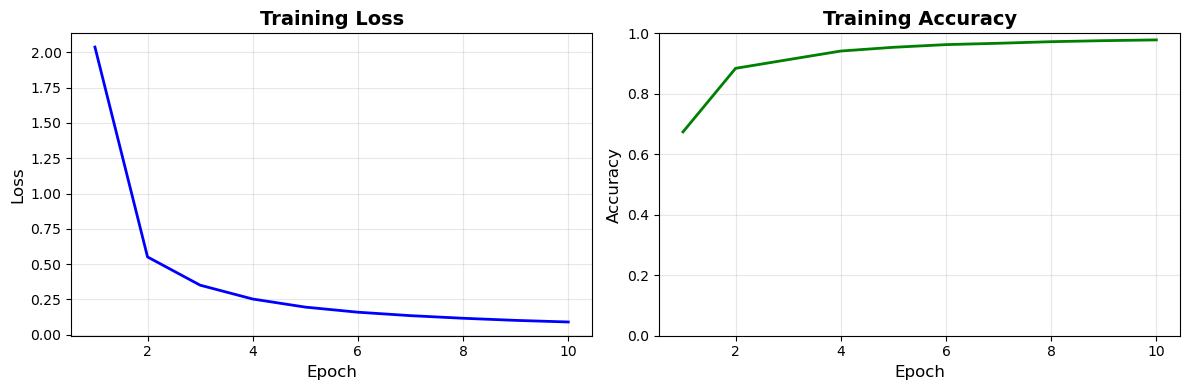


🎯 Final Results:
   Initial Accuracy: 67.41%
   Final Accuracy:   97.82%
   Improvement:      30.42%
   Final Loss:       0.0898


In [18]:
# ============================================================================
# VISUALIZE TRAINING RESULTS
# ============================================================================

import matplotlib.pyplot as plt

# Plot training loss and accuracy
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss plot
ax1.plot(range(1, len(history['loss']) + 1), history['loss'], 'b-', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Training Loss', fontsize=14, fontweight='bold')
ax1.grid(True, alpha=0.3)

# Accuracy plot
ax2.plot(range(1, len(history['accuracy']) + 1), history['accuracy'], 'g-', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Training Accuracy', fontsize=14, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()

print(f"\n🎯 Final Results:")
print(f"   Initial Accuracy: {history['accuracy'][0]:.2%}")
print(f"   Final Accuracy:   {history['accuracy'][-1]:.2%}")
print(f"   Improvement:      {(history['accuracy'][-1] - history['accuracy'][0]):.2%}")
print(f"   Final Loss:       {history['loss'][-1]:.4f}")